In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.neighbors import NearestNeighbors

In [27]:
df = pd.read_csv("../data/processed/kc_house_featured.csv")

In [28]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20467 entries, 0 to 20466
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    20467 non-null  int64  
 1   date                  20467 non-null  object 
 2   price                 20467 non-null  float64
 3   bedrooms              20467 non-null  int64  
 4   bathrooms             20467 non-null  float64
 5   sqft_living           20467 non-null  int64  
 6   sqft_lot              20467 non-null  int64  
 7   floors                20467 non-null  float64
 8   waterfront            20467 non-null  int64  
 9   view                  20467 non-null  int64  
 10  condition             20467 non-null  int64  
 11  grade                 20467 non-null  int64  
 12  sqft_above            20467 non-null  int64  
 13  sqft_basement         20467 non-null  int64  
 14  yr_built              20467 non-null  int64  
 15  yr_renovated       

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,distance_city_center
count,2.046700e+04,2.046700e+04,20467.000000,20467.000000,20467.000000,2.046700e+04,20467.000000,20467.000000,20467.000000,20467.000000,...,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000
mean,4.603223e+09,4.769846e+05,3.329750,2.051632,1975.558167,1.461041e+04,1.476035,0.002980,0.172668,3.406361,...,267.227195,1970.811013,74.681145,98078.555773,47.556888,-122.213265,1922.255191,12447.084526,44.188987,18.853515
std,2.877364e+09,2.083713e+05,0.912885,0.711906,774.833460,4.010956e+04,0.537033,0.054513,0.640950,0.647228,...,409.031661,29.160540,378.761647,53.336953,0.141038,0.142412,614.932010,26538.592250,29.160540,10.685155
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,0.000000,0.983119
25%,2.131701e+09,3.150000e+05,3.000000,1.500000,1400.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.460400,-122.330000,1470.000000,5046.000000,19.000000,10.087354
50%,3.905082e+09,4.375000e+05,3.000000,2.000000,1860.000000,7.500000e+03,1.000000,0.000000,0.000000,3.000000,...,0.000000,1974.000000,0.000000,98065.000000,47.567000,-122.232000,1800.000000,7542.000000,41.000000,16.952017
75%,7.338101e+09,6.000000e+05,4.000000,2.500000,2431.000000,1.031900e+04,2.000000,0.000000,0.000000,4.000000,...,510.000000,1996.000000,0.000000,98118.000000,47.679800,-122.123000,2280.000000,9883.500000,64.000000,25.679861
max,9.900000e+09,1.127500e+06,33.000000,7.500000,7480.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,...,2720.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5380.000000,871200.000000,115.000000,77.093790


In [29]:
df[["lat","long"]].head()

,lat,long
0,47.5112,-122.257
1,47.7210,-122.319
2,47.7379,-122.233
3,47.5208,-122.393
4,47.6168,-122.045


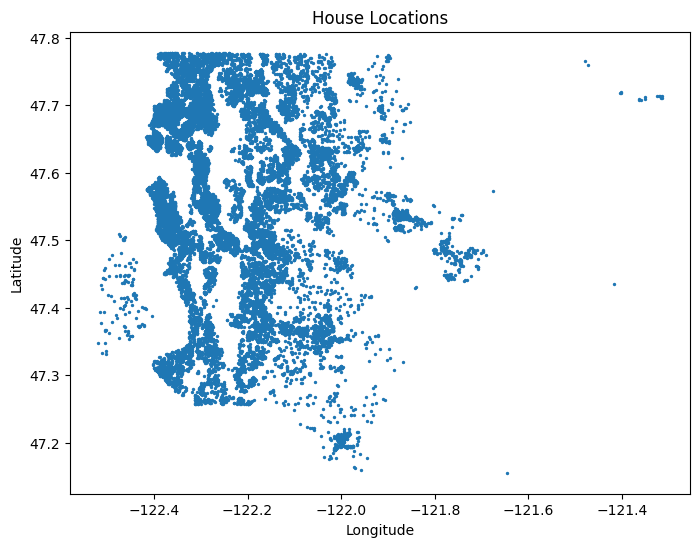

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["long"],
    df["lat"],
    s=2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations")

plt.show()

Every house will be treated as a Node.

Neighbouring houses will be connected using KNN in Day 2.

In [31]:
coords = df[["lat","long"]]

In [32]:
knn = NearestNeighbors(
    n_neighbors=6
)

knn.fit(coords)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [33]:
distances, indices = knn.kneighbors(coords)

In [34]:
print(indices[:5])

print(distances[:5])

[[    0  6008 16029  5519  2266  5138]
 [    1 15618 12369  1998 18423   327]
 [    2 13409  4738 14952  1332 10322]
 [    3  3421  4719 13897 15381 13603]
 [    4  5446 10245  7071  4898  2135]]
[[0.         0.0004     0.0005     0.00100499 0.00104403 0.00208806]
 [0.         0.00100499 0.00104403 0.00141421 0.00141421 0.00156205]
 [0.         0.0013     0.00148661 0.0020025  0.00205913 0.00211896]
 [0.         0.0005     0.0006     0.00238537 0.00250799 0.0032311 ]
 [0.         0.0001     0.0008     0.00104403 0.00128062 0.0021    ]]


In [35]:
house = 0

print(indices[house])

print(distances[house])

[    0  6008 16029  5519  2266  5138]
[0.         0.0004     0.0005     0.00100499 0.00104403 0.00208806]


Each house is connected to its five nearest neighbouring houses.

Neighbour selection is based on geographical distance.

In [36]:
G = nx.Graph()

In [37]:
for i in range(len(df)):
    G.add_node(i)

In [38]:
for i in range(len(indices)):

    for j in indices[i][1:]:

        G.add_edge(i,j)

In [39]:
print(G.number_of_nodes())

print(G.number_of_edges())

20467
63958


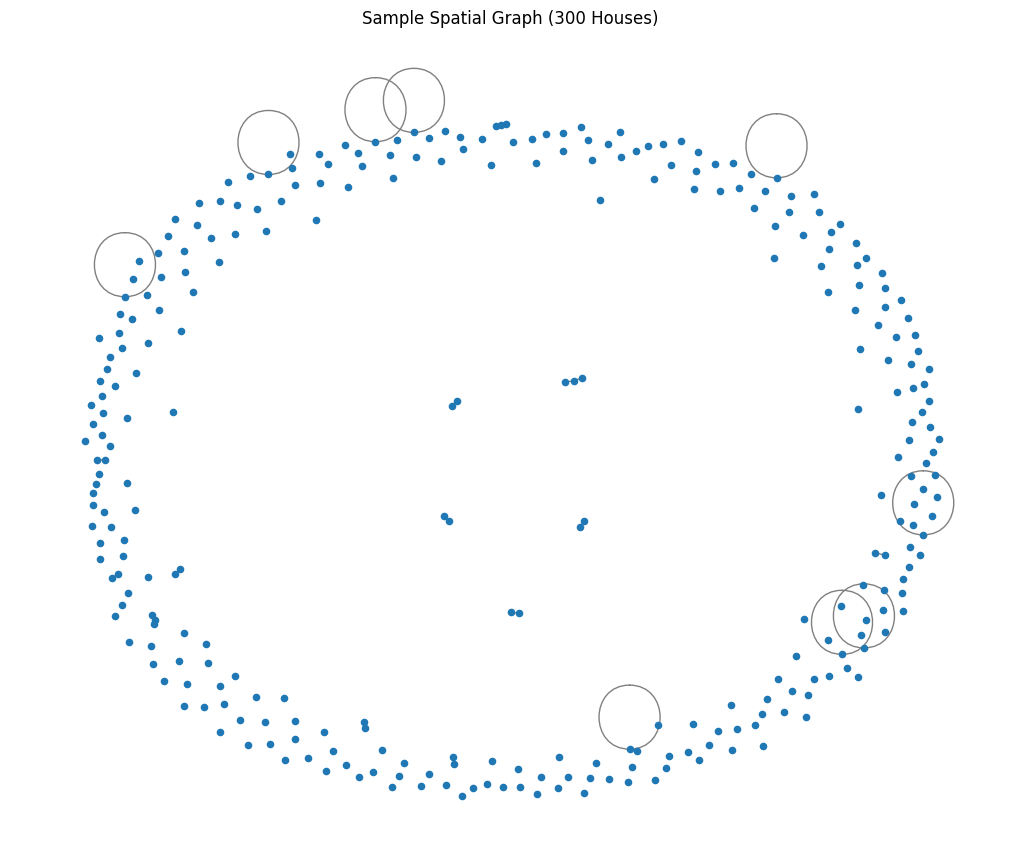

In [40]:
import matplotlib.pyplot as plt
import networkx as nx

sample_nodes = list(G.nodes())[:300]
sample_graph = G.subgraph(sample_nodes)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(sample_graph, seed=42)

nx.draw(
    sample_graph,
    pos,
    node_size=20,
    with_labels=False,
    edge_color="gray"
)

plt.title("Sample Spatial Graph (300 Houses)")
plt.show()


In [41]:
plt.savefig("../dashboard/sample_spatial_graph.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [42]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average Degree: {(2 * G.number_of_edges()) / G.number_of_nodes():.2f}")

Nodes: 20467
Edges: 63958
Average Degree: 6.25


### Graph Construction

A spatial graph was constructed using K-Nearest Neighbors (KNN), where each house is represented as a node and edges connect geographically nearby houses.

Since the complete graph contains more than 20,000 nodes, visualizing the entire network is computationally expensive and difficult to interpret. Therefore, a representative sample of 300 nodes is visualized.

In [43]:
df["degree"] = [G.degree(node) for node in G.nodes()]

In [44]:
avg_neighbor_price = []

for node in G.nodes():
    neighbors = list(G.neighbors(node))

    if len(neighbors) == 0:
        avg_neighbor_price.append(0)
    else:
        avg_price = df.loc[neighbors, "price"].mean()
        avg_neighbor_price.append(avg_price)

df["avg_neighbor_price"] = avg_neighbor_price

In [45]:
avg_distance = distances[:,1:].mean(axis=1)

df["avg_neighbor_distance"] = avg_distance

In [46]:
df[[
    "degree",
    "avg_neighbor_price",
    "avg_neighbor_distance"
]].head()

,degree,avg_neighbor_price,avg_neighbor_distance
0,6,306833.333333,0.001007
1,7,407785.714286,0.001288
2,7,483942.857143,0.001793
3,5,633300.000000,0.001845
4,6,516166.666667,0.001065


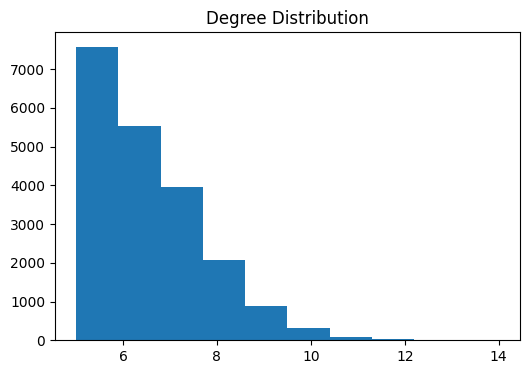

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df["degree"], bins=10)

plt.title("Degree Distribution")

plt.show()

In [48]:
df.to_csv(
    "../data/processed/kc_house_graph_features.csv",
    index=False
)

### Spatial Embeddings

Three graph-based spatial features were generated:

- Degree (number of neighbouring houses)
- Average neighbour price
- Average neighbour distance

These features capture the spatial relationship between nearby properties and will be used in the next phase of the project.

In [49]:
neighbor_price_std = []

for node in G.nodes():
    neighbors = list(G.neighbors(node))

    if len(neighbors) == 0:
        neighbor_price_std.append(0)
    else:
        neighbor_price_std.append(
            df.loc[neighbors, "price"].std()
        )

df["neighbor_price_std"] = neighbor_price_std

In [50]:
clustering = nx.clustering(G)

df["clustering_coefficient"] = pd.Series(clustering)

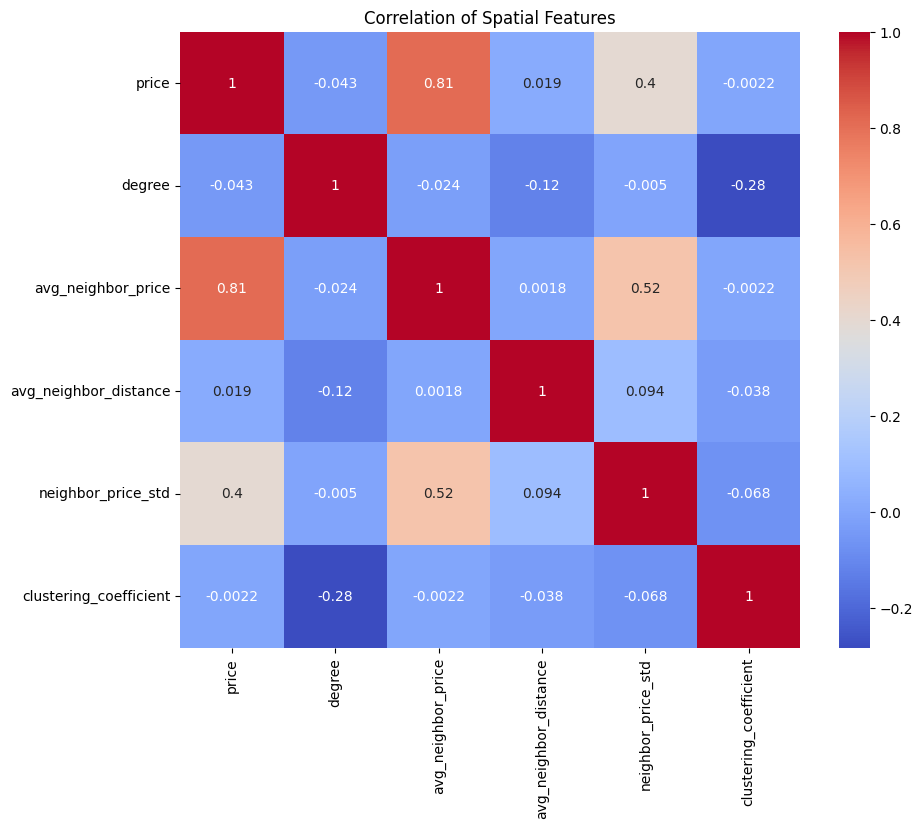

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

graph_features = [
    "price",
    "degree",
    "avg_neighbor_price",
    "avg_neighbor_distance",
    "neighbor_price_std",
    "clustering_coefficient"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[graph_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Spatial Features")
plt.show()

In [52]:
df[
    [
        "degree",
        "avg_neighbor_price",
        "avg_neighbor_distance",
        "neighbor_price_std",
        "clustering_coefficient"
    ]
].describe()

,degree,avg_neighbor_price,avg_neighbor_distance,neighbor_price_std,clustering_coefficient
count,20467.000000,2.046700e+04,20467.000000,20467.000000,20467.000000
mean,6.249866,4.760903e+05,0.002187,102747.591454,0.604105
std,1.311500,1.773983e+05,0.003504,59554.215489,0.174989
min,5.000000,1.419500e+05,0.000060,2958.039892,0.100000
25%,5.000000,3.306458e+05,0.001235,56657.409783,0.476190
50%,6.000000,4.536000e+05,0.001708,89955.822491,0.600000
75%,7.000000,5.957500e+05,0.002399,138585.599937,0.700000
max,14.000000,1.049148e+06,0.285239,367684.165960,1.000000


In [53]:
df.to_csv(
    "../data/processed/kc_house_graph_features.csv",
    index=False
)

## Additional Spatial Feature Engineering

To improve the quality of the spatial representation, additional graph-based features were generated:

- Neighbor Price Standard Deviation
- Clustering Coefficient

These features capture local price variability and neighborhood connectivity, providing richer spatial information for future machine learning models.